В цьому ноутбуці відбуваєтся тестування рандомних активів на рандомному проміжку часу. Метою є візуальна перевірка коректність роботи бектест алгоритму

In [1]:
import os
os.chdir("..")

In [3]:
import pandas as pd
import numpy as np
import random
import yaml

from app import BacktestDCA
from ploter import ploter

/Users/aleksejkitajskij/Desktop/DCA/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# stocks

In [4]:
df_stocks = pd.read_csv("data/test_crypto.csv", index_col=0, parse_dates=True)
df_stocks.dropna(how='all', inplace=True, axis=1)
df_stocks.dropna(how='all', inplace=True, axis=0)
df_stocks

,BTC,ETH,XRP,USDT,BCH,LTC,EOS,BNB,BSV,XLM,...,VET,BAT,OMG,SNX,COMP,YFI,UMA,ZRX,ICX,QTUM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-13,10214.379883,268.099243,0.326706,0.998579,474.317993,80.403427,5.341575,25.440100,359.041138,0.082655,...,0.008026,0.295389,1.280141,0.932967,NaN,NaN,NaN,0.320865,0.394342,2.842507
2020-02-14,10312.116211,284.217499,0.334822,1.000114,491.160645,82.990349,5.361947,26.296959,360.390015,0.085796,...,0.008323,0.311020,1.370907,0.992797,NaN,NaN,NaN,0.345264,0.400229,3.015611
2020-02-15,9889.424805,264.728577,0.306236,0.999128,437.664948,76.513245,4.743118,24.149651,310.077820,0.079246,...,0.007440,0.280342,1.289413,0.949770,NaN,NaN,NaN,0.317226,0.360399,2.677241
2020-02-16,9934.433594,259.894714,0.295034,0.999272,415.940643,75.152588,4.412250,23.466389,285.867523,0.075079,...,0.007133,0.264260,1.190897,0.945258,NaN,NaN,NaN,0.299002,0.348740,2.511193
2020-02-17,9690.142578,266.363434,0.286572,0.998474,409.344574,73.251305,4.346360,23.551378,309.441620,0.071851,...,0.006756,0.266563,1.169630,1.011205,NaN,NaN,NaN,0.291352,0.344687,2.499368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,68233.312500,2104.708252,1.340259,0.999024,466.334564,53.917908,0.075516,617.049194,13.852106,0.167265,...,0.006763,0.096228,0.054769,0.287147,NaN,2486.911377,0.409303,0.103136,0.034007,0.887649
2026-04-01,68078.554688,2138.737061,1.347766,0.999800,454.311554,53.805855,0.078632,610.622986,14.003111,0.169253,...,0.006885,0.099325,0.055448,0.281543,NaN,2456.119385,0.409600,0.104537,0.035458,0.930321
2026-04-02,66888.570312,2056.852539,1.318691,0.999892,444.056213,52.260174,0.076542,583.136841,14.614312,0.163015,...,0.006740,0.094341,0.053399,0.278585,NaN,2413.258057,0.387646,0.102121,0.035270,0.879604


In [5]:
sequence_length = 365 * 3

start = random.randint(0, len(df_stocks) - sequence_length)
prices = df_stocks.iloc[start:start + sequence_length]
prices.index.min(), prices.index.max()

(Timestamp('2023-03-31 00:00:00'), Timestamp('2026-03-29 00:00:00'))

In [6]:
token_num = 10

random_token = random.sample(df_stocks.columns.tolist(), token_num)
random_token

['XLM', 'BAT', 'DOGE', 'ADA', 'YFI', 'USDT', 'ETH', 'SNX', 'BTC', 'OMG']

In [7]:
strategy = {}

08:11:48 - cmdstanpy - INFO - Chain [1] start processing
08:11:48 - cmdstanpy - INFO - Chain [1] done processing


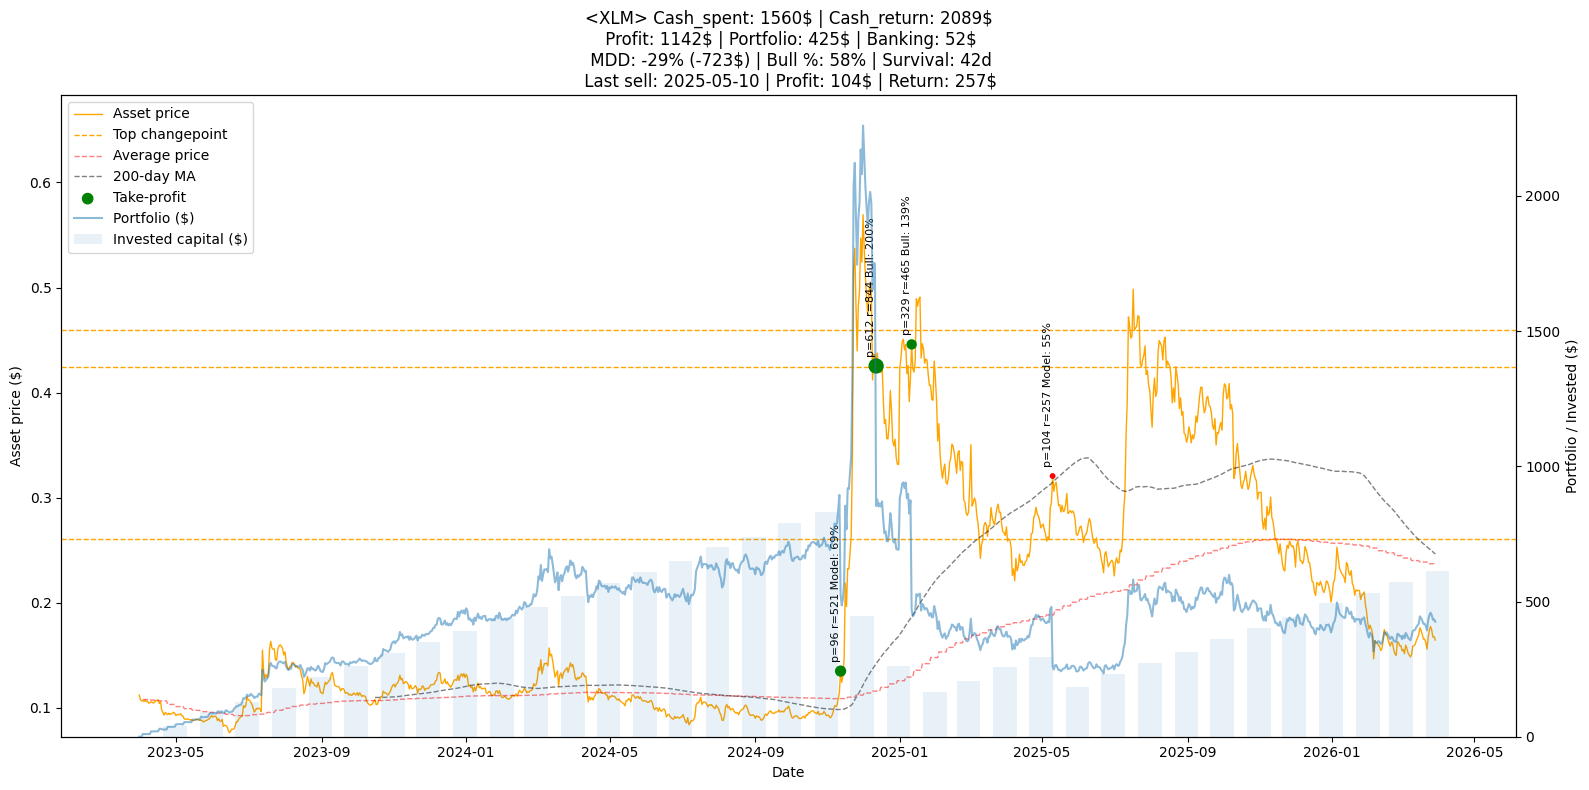

08:11:52 - cmdstanpy - INFO - Chain [1] start processing
08:11:52 - cmdstanpy - INFO - Chain [1] done processing


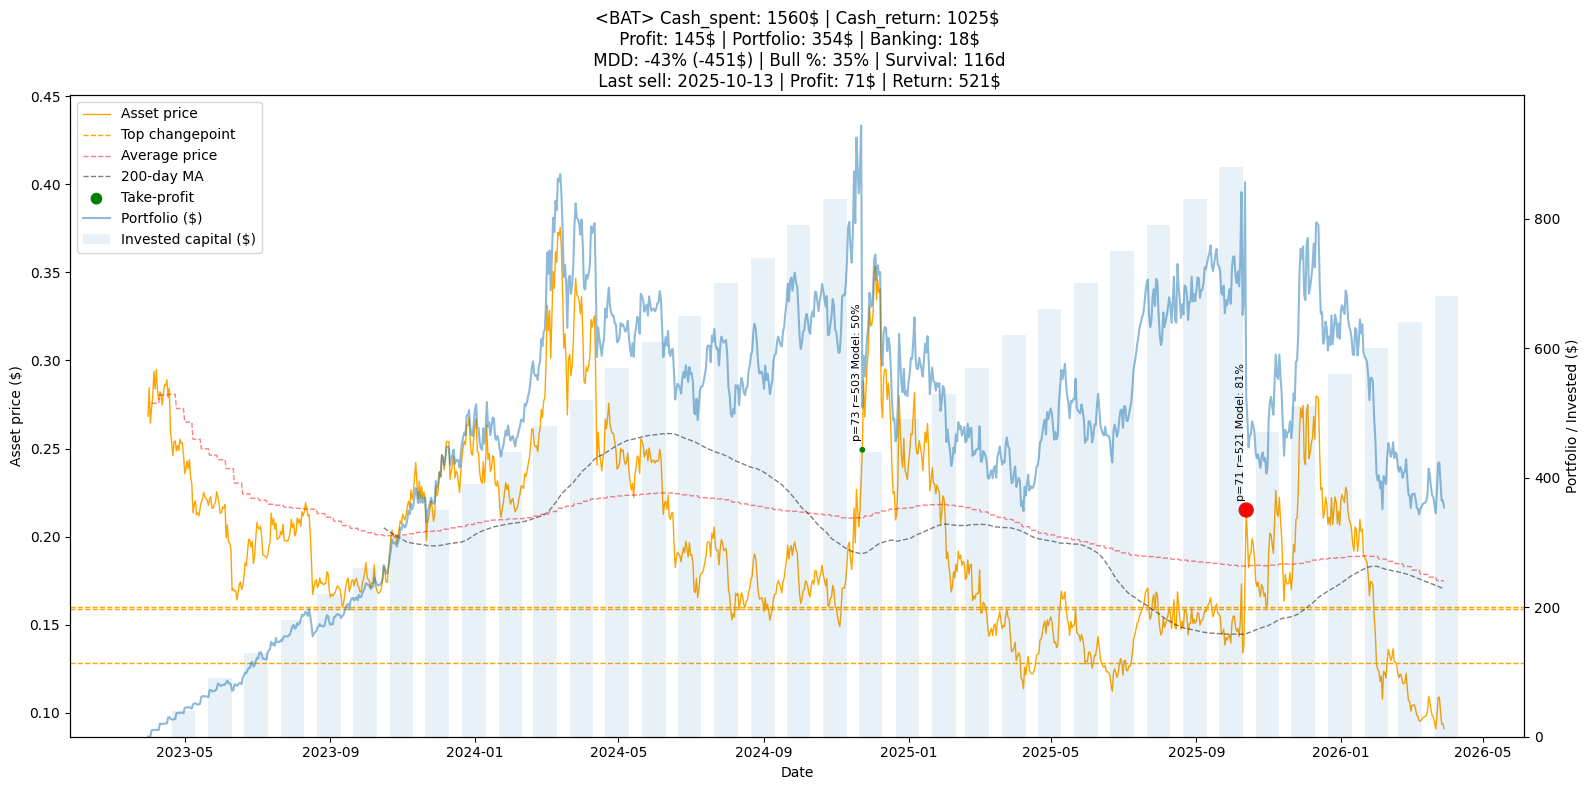

08:11:59 - cmdstanpy - INFO - Chain [1] start processing
08:11:59 - cmdstanpy - INFO - Chain [1] done processing


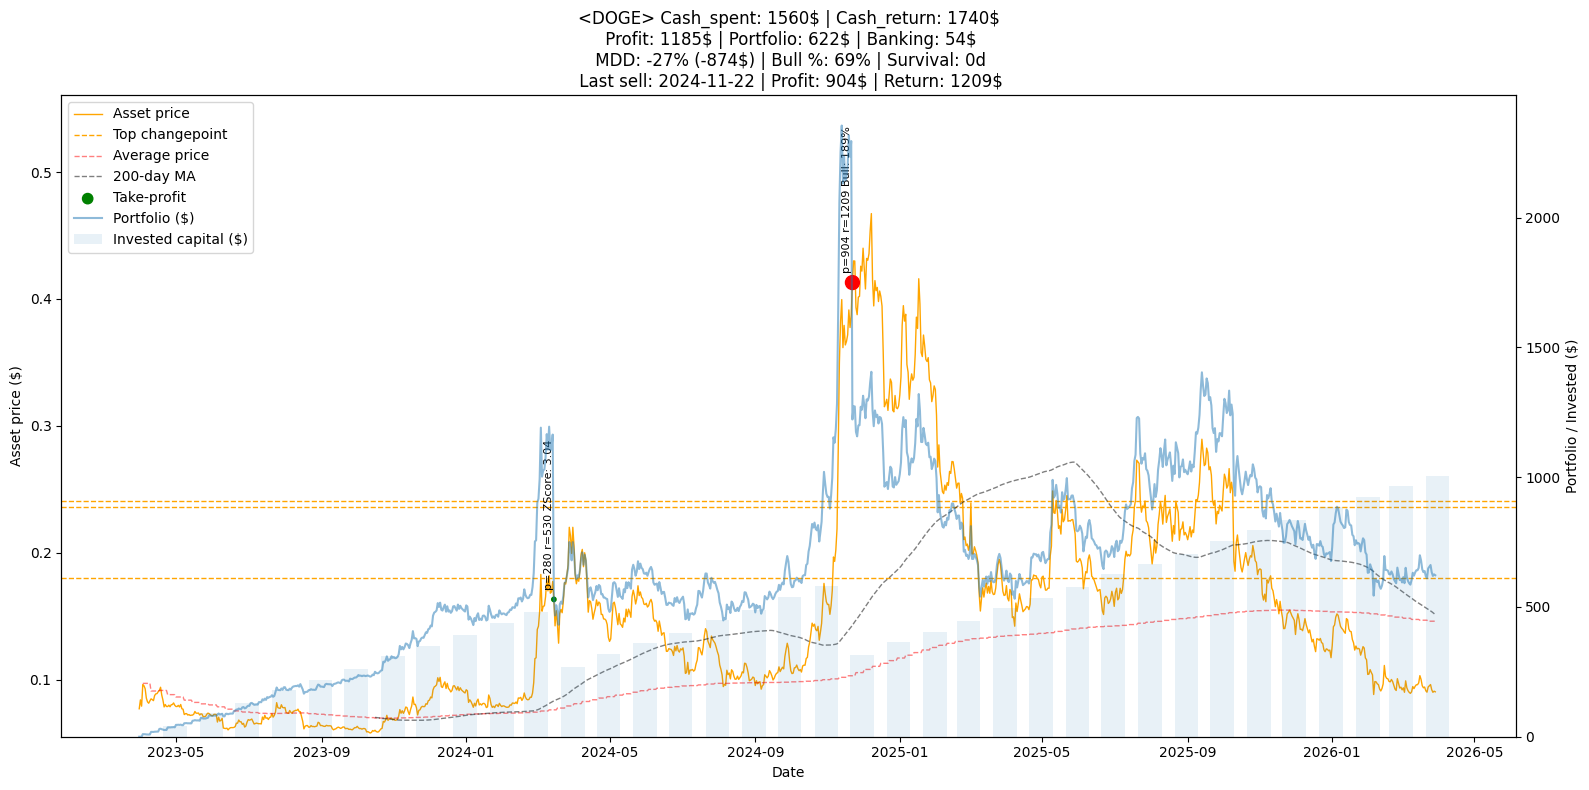

08:12:04 - cmdstanpy - INFO - Chain [1] start processing
08:12:04 - cmdstanpy - INFO - Chain [1] done processing


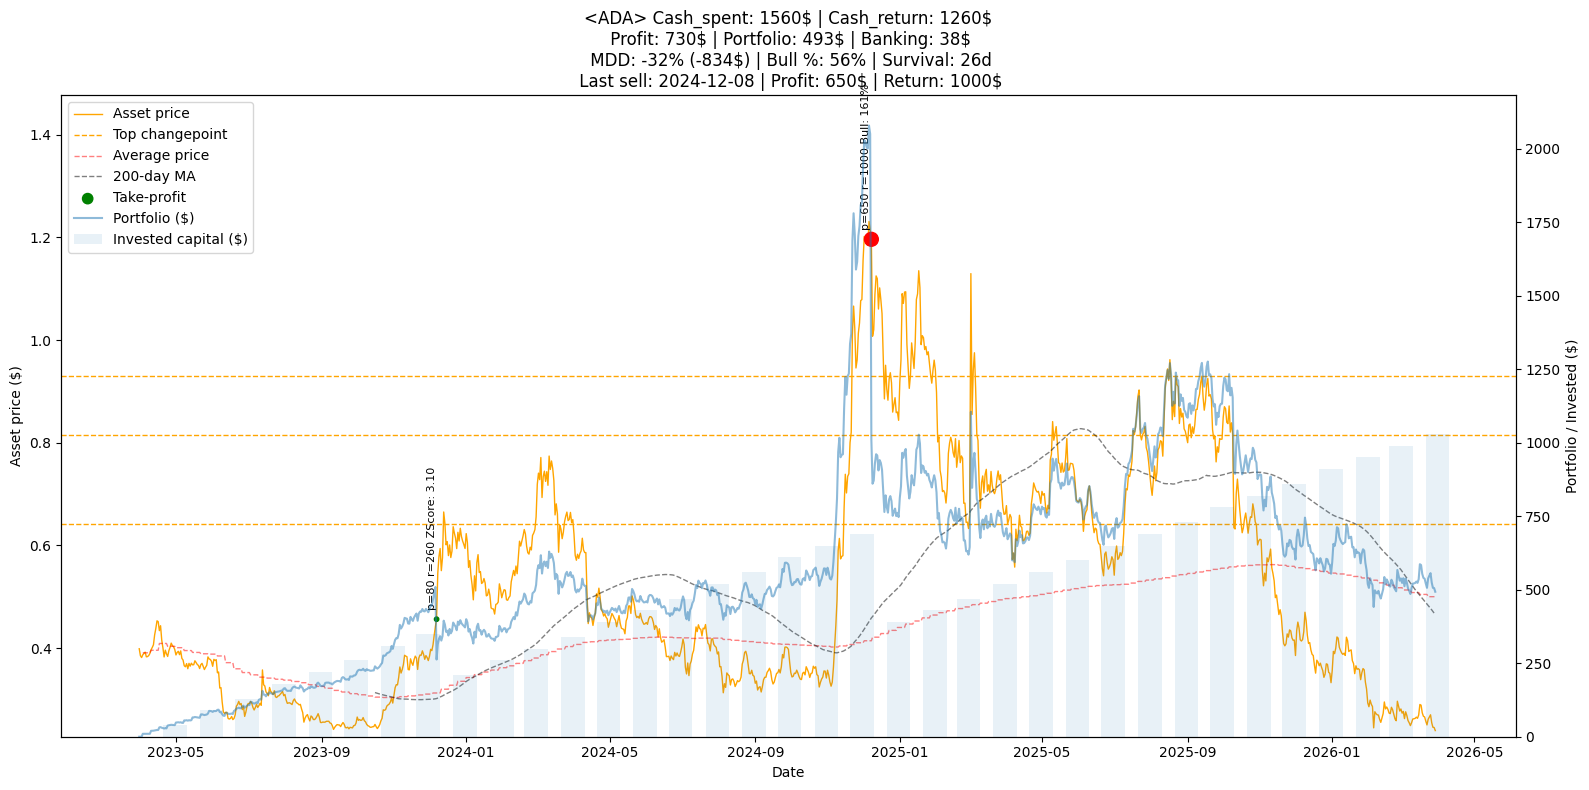

08:12:05 - cmdstanpy - INFO - Chain [1] start processing
08:12:06 - cmdstanpy - INFO - Chain [1] done processing


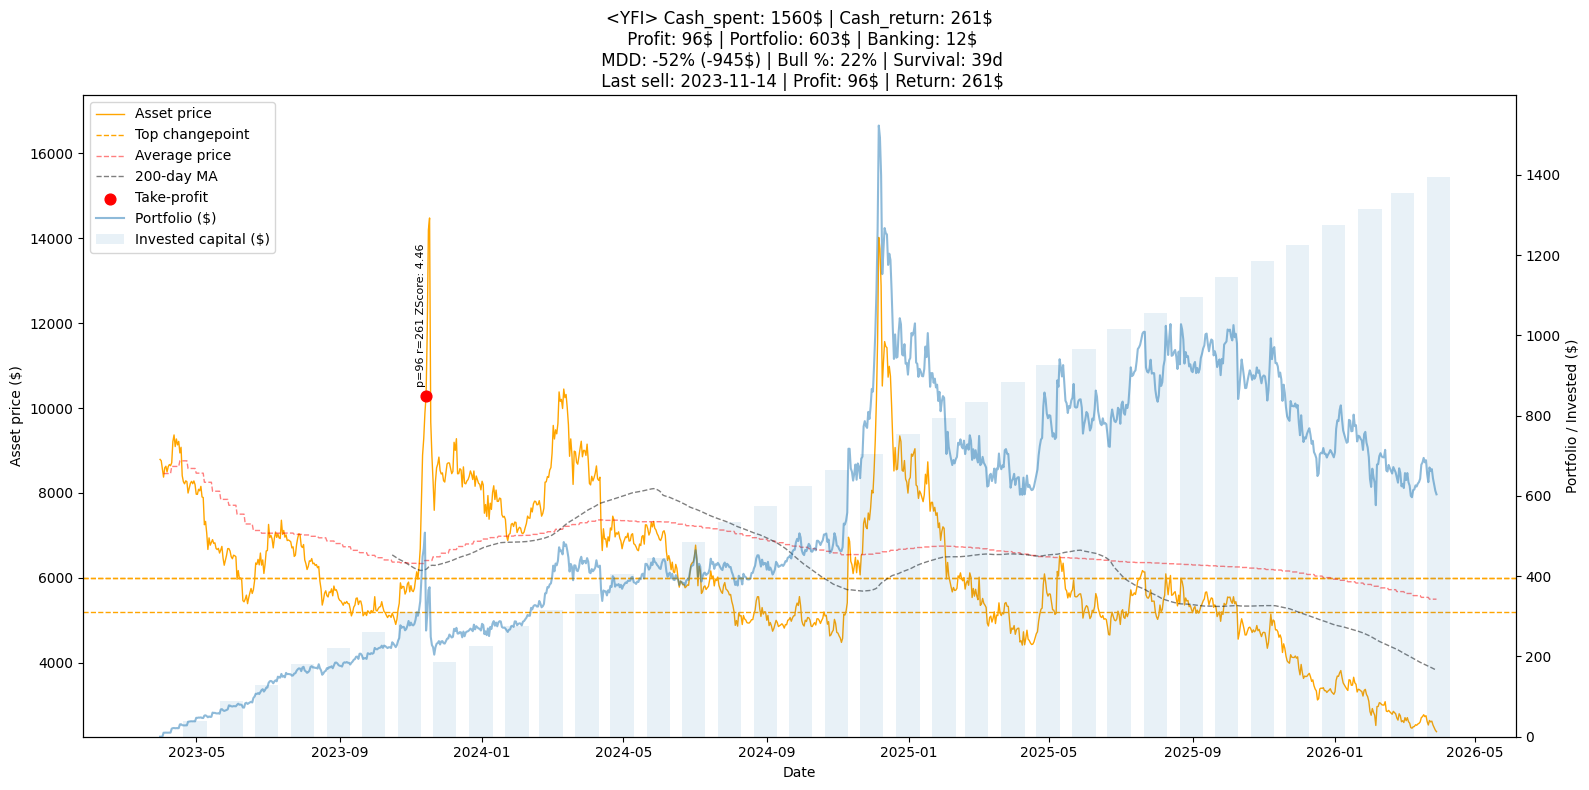

08:12:06 - cmdstanpy - INFO - Chain [1] start processing
08:12:06 - cmdstanpy - INFO - Chain [1] done processing


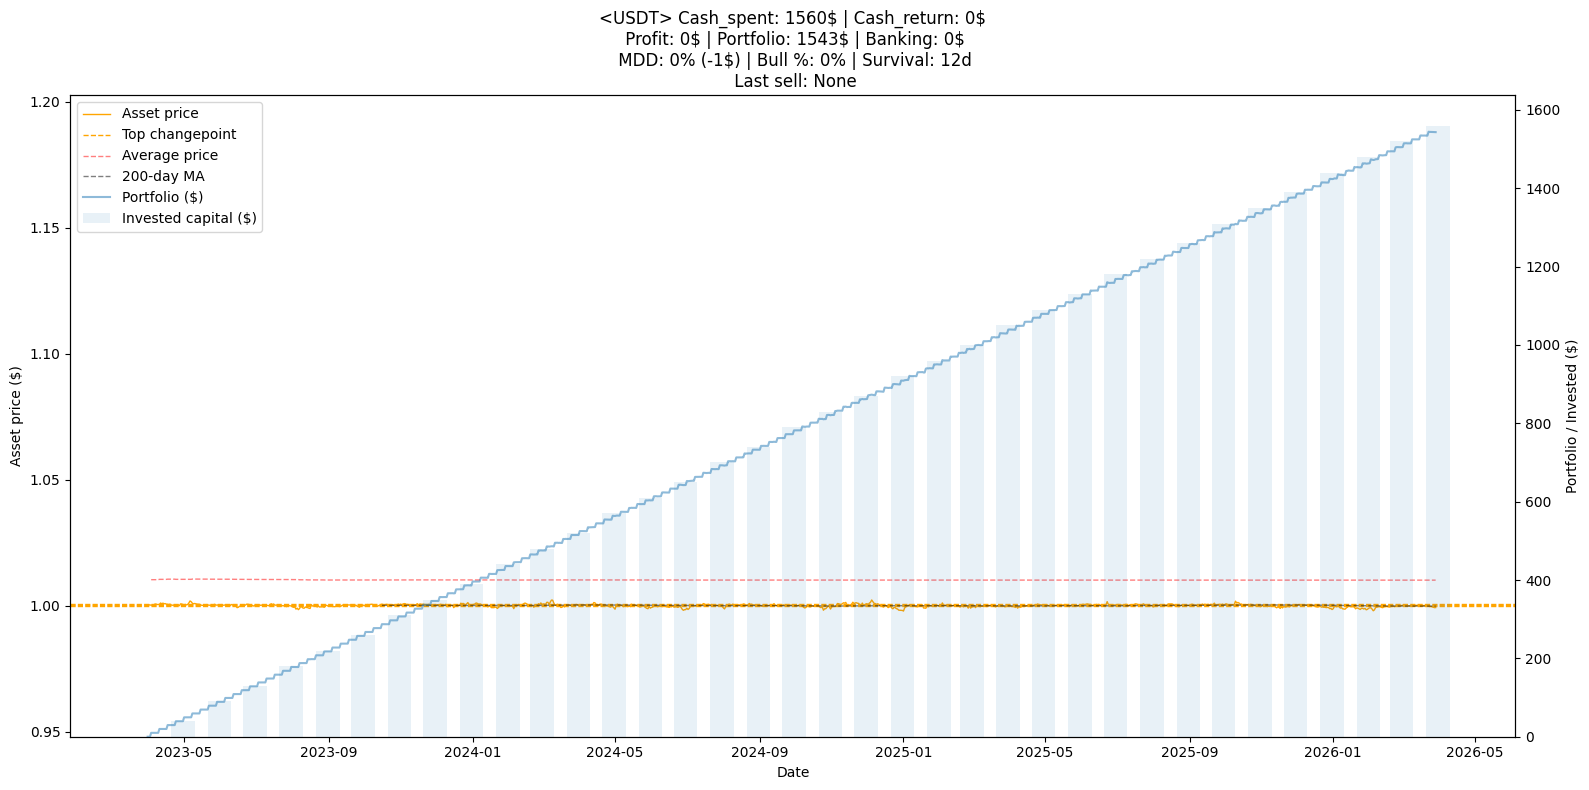

08:12:12 - cmdstanpy - INFO - Chain [1] start processing
08:12:12 - cmdstanpy - INFO - Chain [1] done processing


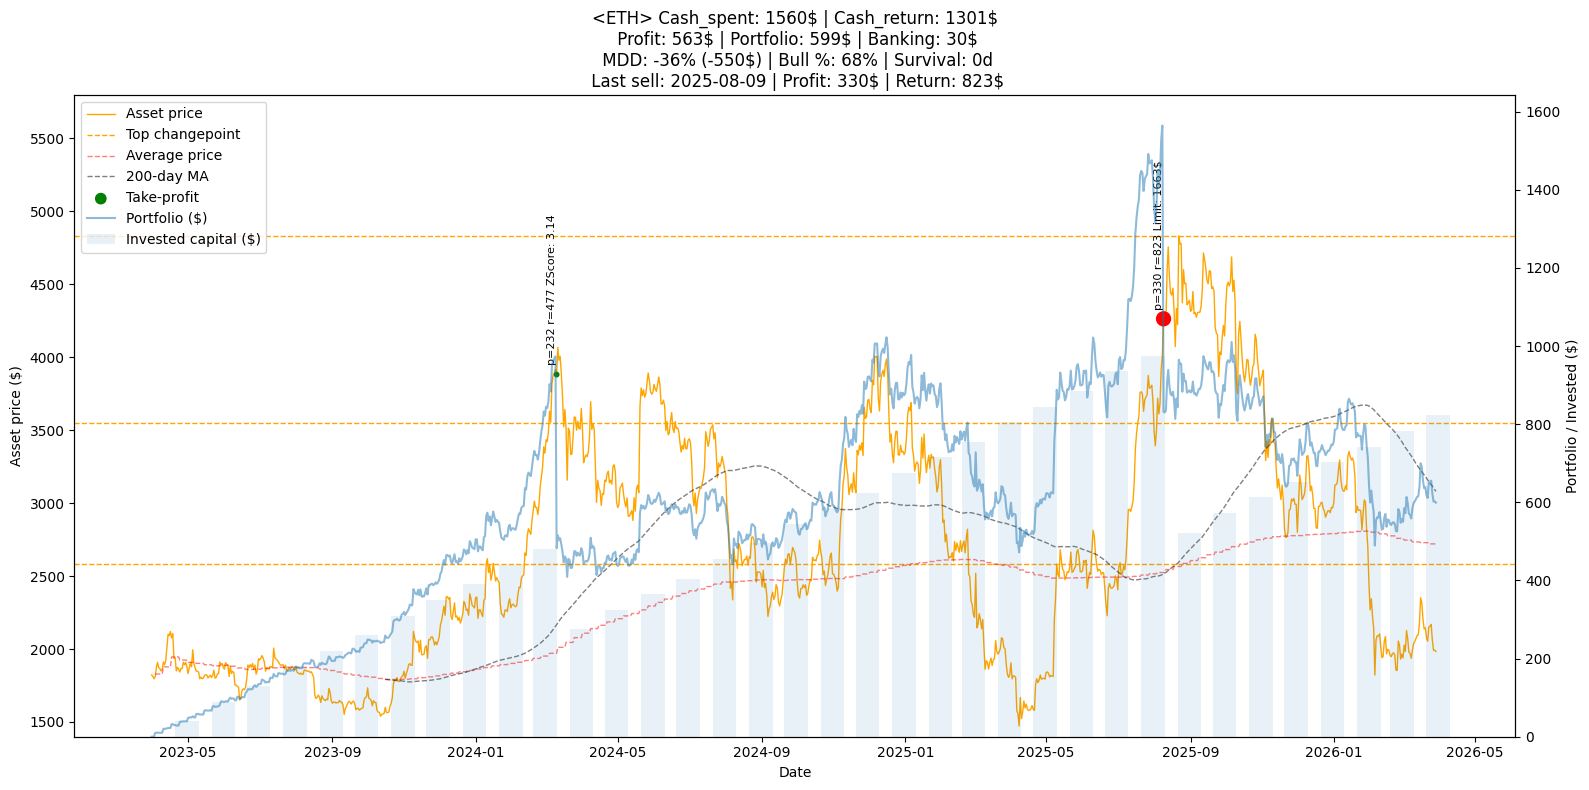

08:12:14 - cmdstanpy - INFO - Chain [1] start processing
08:12:14 - cmdstanpy - INFO - Chain [1] done processing


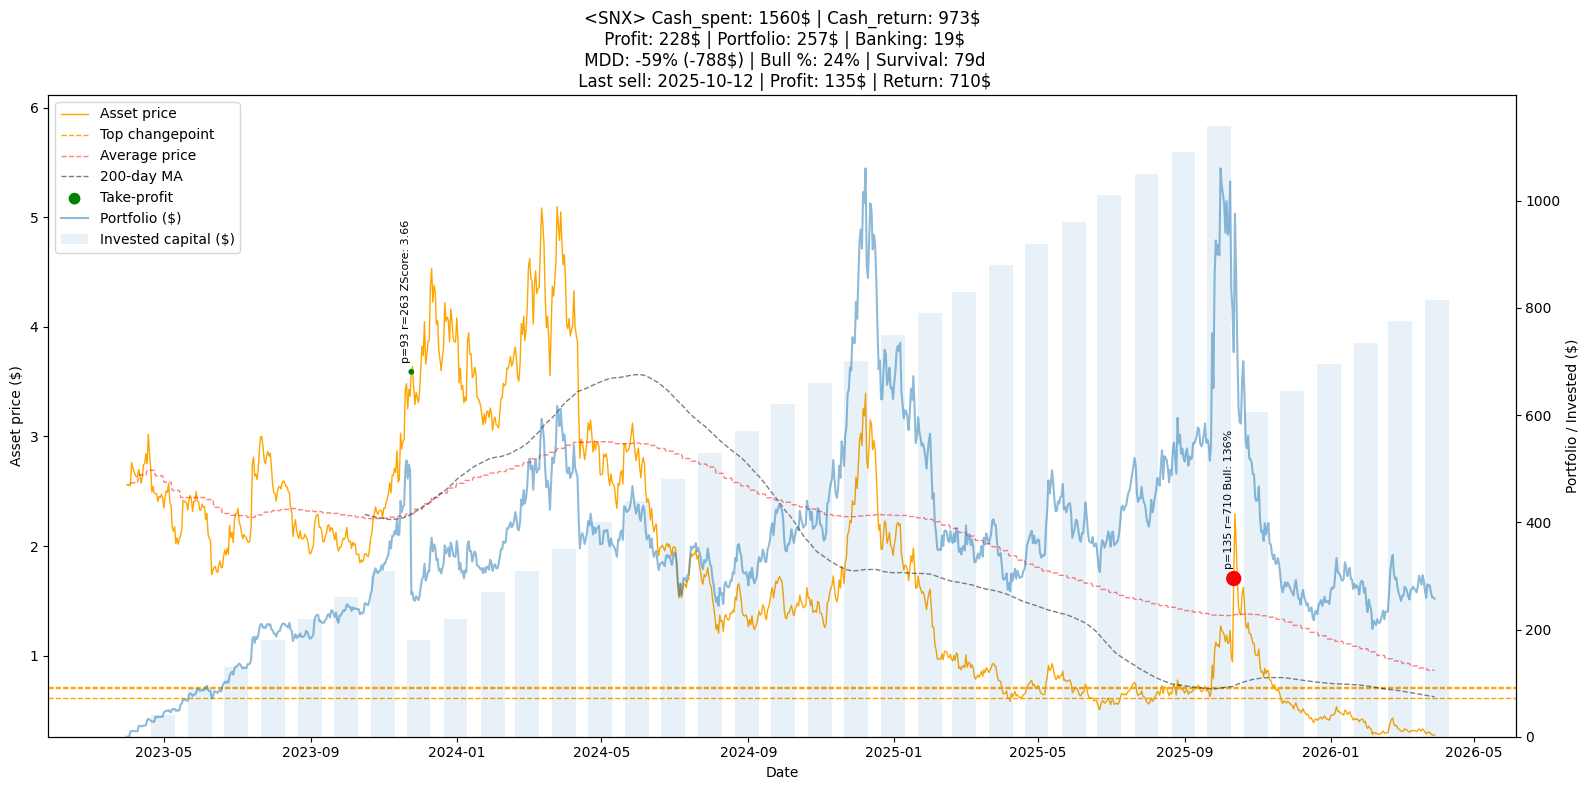

08:12:21 - cmdstanpy - INFO - Chain [1] start processing
08:12:22 - cmdstanpy - INFO - Chain [1] done processing


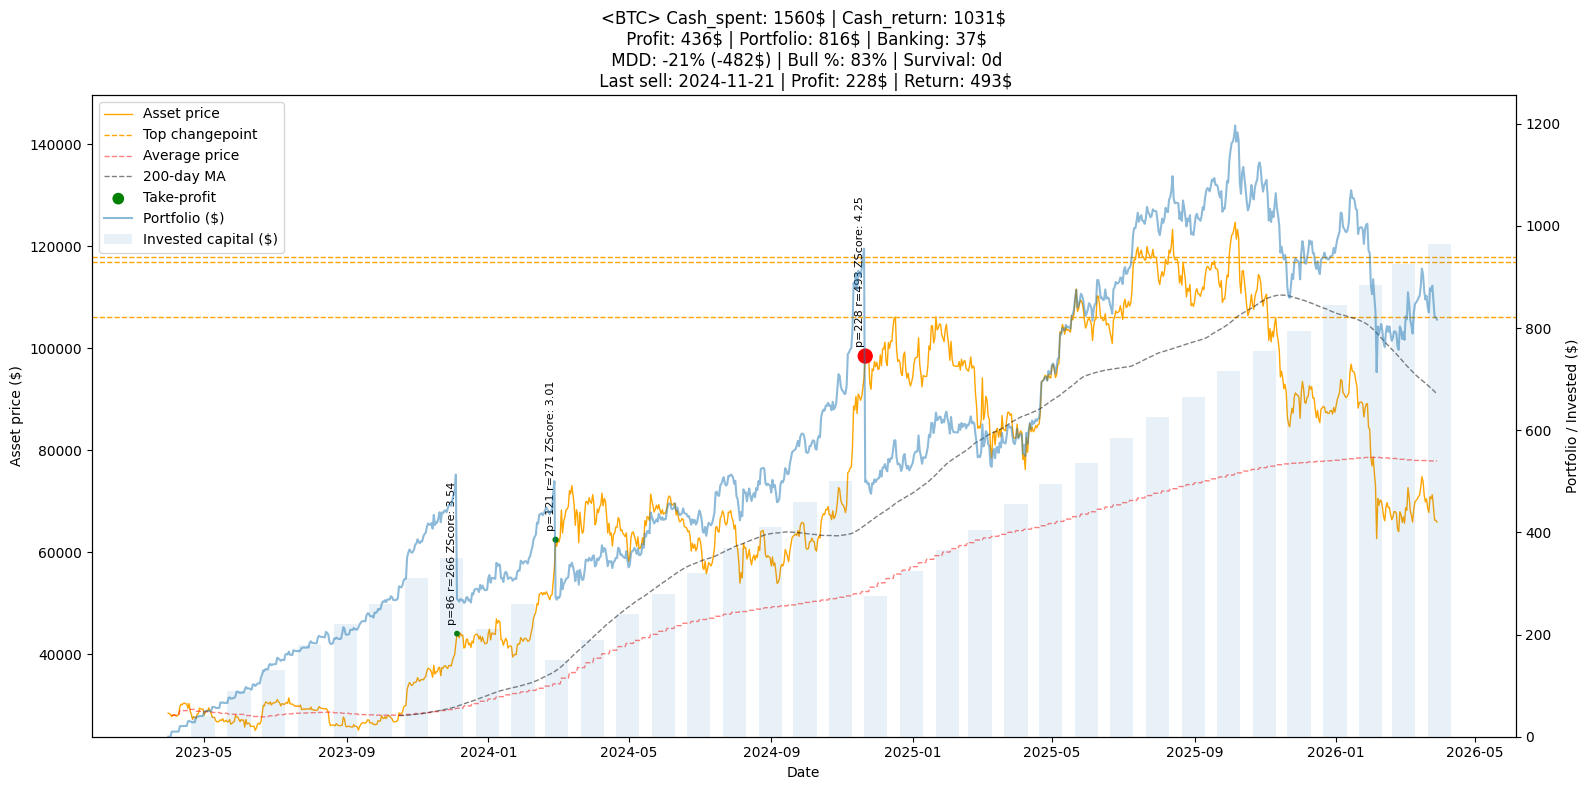

08:12:23 - cmdstanpy - INFO - Chain [1] start processing
08:12:23 - cmdstanpy - INFO - Chain [1] done processing


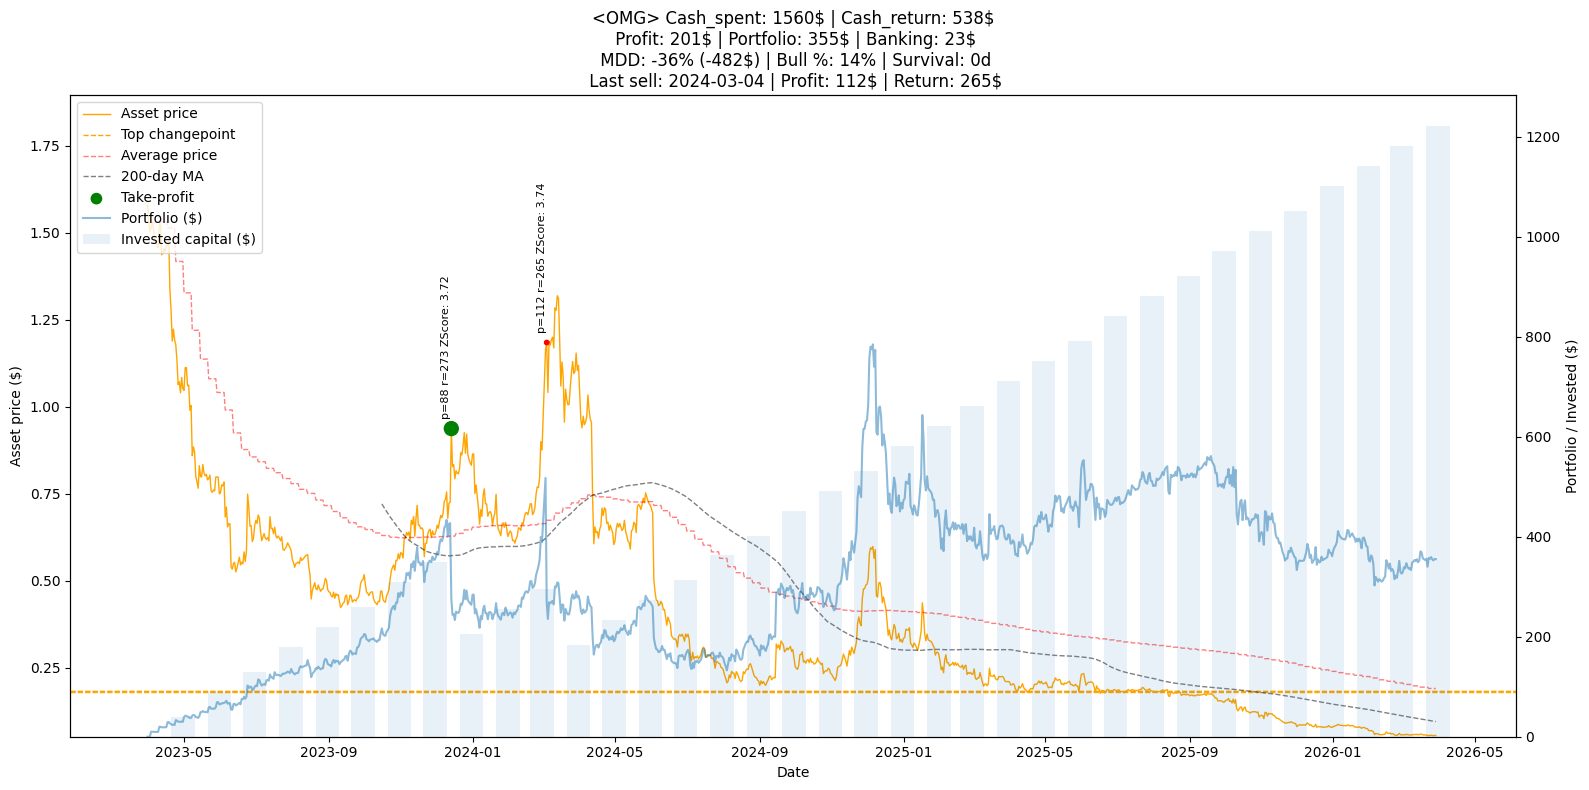

Total invested: $15600.00
Total profit: $4726.00
Total return: $10218.00
Total value: $16285.00


In [8]:
total_invested = 0
total_profit = 0
total_return = 0
total_value = 0

for stock in random_token:
    stock_prices = prices[stock]
    stock_prices = stock_prices.dropna()

    try:
        bt = BacktestDCA(
        target=stock,
        prices=stock_prices,
        strategy=strategy
        )
        result, metrics = bt.run()
        ploter(metrics=metrics, history=result)
    except Exception as e:
        print(f"Error backtesting {stock}: {e}")
        continue

    total_invested += metrics['Cash_spent']
    total_profit += metrics['Profit']
    total_return += metrics['Cash_return']
    total_value += metrics['Portfolio'] + metrics['Cash_return']

print(f"Total invested: ${total_invested:.2f}")
print(f"Total profit: ${total_profit:.2f}")
print(f"Total return: ${total_return:.2f}")
print(f"Total value: ${total_value:.2f}")

In [9]:
result

,Price,Qty,Cost_basis,Cash_spent,Profit,Returns,Trigger_msg,Portfolio,Average_price
Date,,,,,,,,,
2023-03-31,1.580498,0.000000,0.0,0.0,0.0,0.0,,0.000000,NaN
2023-04-01,1.535757,0.000000,0.0,0.0,0.0,0.0,,0.000000,NaN
2023-04-02,1.504674,0.000000,0.0,0.0,0.0,0.0,,0.000000,NaN
2023-04-03,1.514557,6.536565,10.0,10.0,0.0,0.0,,9.900000,1.529856
2023-04-04,1.529806,6.536565,10.0,10.0,0.0,0.0,,9.999676,1.529856
...,...,...,...,...,...,...,...,...,...
2026-03-25,0.055963,6419.868009,1222.5,1560.0,0.0,0.0,,359.275063,0.190424
2026-03-26,0.055290,6419.868009,1222.5,1560.0,0.0,0.0,,354.954494,0.190424
2026-03-27,0.054949,6419.868009,1222.5,1560.0,0.0,0.0,,352.765330,0.190424


In [10]:
metrics

{'Target': 'OMG',
 'Cash_spent': 1560,
 'Cash_return': 538,
 'Portfolio': 355,
 'Profit': 201,
 'Bull_history': 14,
 'Num_take_profits': 2,
 'MDD': -36,
 'MDD_usd': -482,
 'Bank_profit': 23,
 'MA200_survival_days': 0.0}